# <span style="color:green">Kwanda Mazibuko, stdnr : 1077167
</span>

# <span style="color:blue">Homework Assignment 1 : Imputation and Further Data Processing
</span>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

from sklearn.impute import KNNImputer
from sklearn.metrics import r2_score

#ignoring warnings
import warnings
warnings.filterwarnings('ignore')

#making sure that we can see all rows and cols
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

## Basic Data Processing

In [2]:
url = "https://raw.githubusercontent.com/kwanda2426/projects/main/geospatial/Merged_Chem.csv"
df = pd.read_csv(url)
df.head()

,Unnamed: 0,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9
2,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0
3,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8
4,4,013L781005,013L,54.973541,-62.054790,50.0,26.0,NaN,22.0,6.0,NaN,120.0,0.85,NaN,2.0,60.0,29.6,40.0,0.6,First Field Duplicate,013L,54.97344,-62.05566,70.0,2.26,0.1,0.9,NaN,20.3,0.2,NaN,0.47,0.29,17.2,6.4,14.0,0.13,26.07,1.47,0.78,0.71,0.84,3.2,1.82,NaN,0.02,51.0,0.28,NaN,0.02,12.2,1.8,0.12,0.14,94.0,0.79,0.072,0.37,13.24,26.1,0.051,1.55,NaN,3.37,NaN,1.1,NaN,0.35,NaN,2.1,0.6,2.05,0.1,28.2,NaN,0.26,NaN,0.6,0.014,0.03,0.12,0.6,34.0,NaN,8.08,0.74,51.1,0.8


In [3]:
# remove index
df = df.reset_index(drop = True)
df.head()

,Unnamed: 0,Unique ID,NTS Sheet,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Sample Type,NTS,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,013L781002,013L,54.989093,-62.019071,40.0,38.0,NaN,43.0,10.0,NaN,70.0,1.00,NaN,2.0,85.0,23,40.0,0.3,Routine,013L,54.98900,-62.01995,57.0,2.89,NaN,1.0,NaN,81.5,0.2,0.02,0.48,0.32,19.1,9.9,22.6,0.17,43.46,1.18,0.65,0.56,1.06,4.6,1.66,NaN,0.03,46.0,0.23,NaN,0.03,10.5,2.9,0.10,0.26,60.0,0.55,0.103,0.39,11.20,52.9,0.042,1.90,NaN,2.84,NaN,1.6,NaN,0.25,NaN,2.3,0.7,1.90,0.1,41.0,NaN,0.20,NaN,0.8,0.021,0.03,0.10,0.3,31.0,NaN,6.04,0.64,44.0,0.9
2,2,013L781003,013L,54.975382,-62.030577,40.0,44.0,NaN,35.0,8.0,NaN,80.0,1.90,NaN,NaN,80.0,33,70.0,0.5,Routine,013L,54.97529,-62.03145,106.0,3.22,0.1,1.6,NaN,26.0,NaN,0.02,0.48,0.35,17.9,8.8,20.8,0.18,49.32,1.30,0.53,0.57,2.19,5.0,1.41,NaN,0.03,66.0,0.20,NaN,0.02,10.0,2.5,0.07,0.20,69.0,0.71,0.080,0.55,9.85,44.7,0.094,2.26,NaN,2.61,NaN,1.6,NaN,0.30,0.02,2.3,1.3,1.76,0.1,31.3,NaN,0.19,NaN,0.8,0.021,0.03,0.08,0.3,45.0,NaN,5.65,0.49,45.1,1.0
3,3,013L781004,013L,54.976331,-62.044913,46.0,30.0,NaN,34.0,8.0,NaN,80.0,0.70,NaN,2.0,90.0,27.2,50.0,0.6,Routine,013L,54.97623,-62.04579,59.0,2.34,0.1,1.1,NaN,49.9,0.1,0.03,0.56,0.29,20.5,8.3,18.3,0.18,33.34,1.42,0.71,0.66,0.75,4.4,1.77,NaN,0.03,51.0,0.28,NaN,0.02,12.3,3.1,0.09,0.26,58.0,0.46,0.107,0.51,12.79,42.4,0.052,2.15,NaN,3.22,NaN,1.7,NaN,0.27,0.04,2.2,0.7,2.20,0.1,40.9,NaN,0.22,NaN,0.7,0.023,0.04,0.09,0.3,17.0,NaN,7.19,0.64,51.4,0.8
4,4,013L781005,013L,54.973541,-62.054790,50.0,26.0,NaN,22.0,6.0,NaN,120.0,0.85,NaN,2.0,60.0,29.6,40.0,0.6,First Field Duplicate,013L,54.97344,-62.05566,70.0,2.26,0.1,0.9,NaN,20.3,0.2,NaN,0.47,0.29,17.2,6.4,14.0,0.13,26.07,1.47,0.78,0.71,0.84,3.2,1.82,NaN,0.02,51.0,0.28,NaN,0.02,12.2,1.8,0.12,0.14,94.0,0.79,0.072,0.37,13.24,26.1,0.051,1.55,NaN,3.37,NaN,1.1,NaN,0.35,NaN,2.1,0.6,2.05,0.1,28.2,NaN,0.26,NaN,0.6,0.014,0.03,0.12,0.6,34.0,NaN,8.08,0.74,51.1,0.8


In [4]:
# changing dtype of while dealing with errors - LOI
df['LOI'] = np.abs(pd.to_numeric(df['LOI'], errors='coerce'))


In [5]:
# summary stat pivoted
df_stats = df.describe().T
df_stats = df_stats.reset_index(drop = False)
df_stats = df_stats.rename(columns = dict([['index', 'column']]))
df_stats.head()

,column,count,mean,std,min,25%,50%,75%,max
0,Unnamed: 0,3442.0,1720.500000,993.764140,0.000000,860.250000,1720.500000,2580.750000,3441.000000
1,Latitude_NAD83,3441.0,55.383663,0.853529,54.005243,54.646363,55.238594,56.136332,56.997959
2,Longitude_NAD83,3441.0,-63.778378,1.451083,-66.997815,-64.884206,-63.316447,-62.667055,-62.001419
3,Old Zn,3441.0,111.829119,104.297344,14.000000,62.000000,90.000000,132.000000,2800.000000
4,Old Cu,3441.0,28.005522,23.771434,2.000000,14.000000,22.000000,34.000000,355.000000


In [6]:
# separating old and new columns
element_lst = [col for col in df.columns if ('Old') in col] + [col for col in df.columns if ('New') in col]

In [7]:
# count of missing/null values
count_lst = []

for element in element_lst:

    count_lst.append([element, (df[element].isna().sum()/len(df))])

count_df = pd.DataFrame(count_lst, columns = ['Element', 'Fraction Missing'])
count_df.head()

,Element,Fraction Missing
0,Old Zn,0.000291
1,Old Cu,0.000291
2,Old Pb,0.377397
3,Old Ni,0.001162
4,Old Co,0.007554


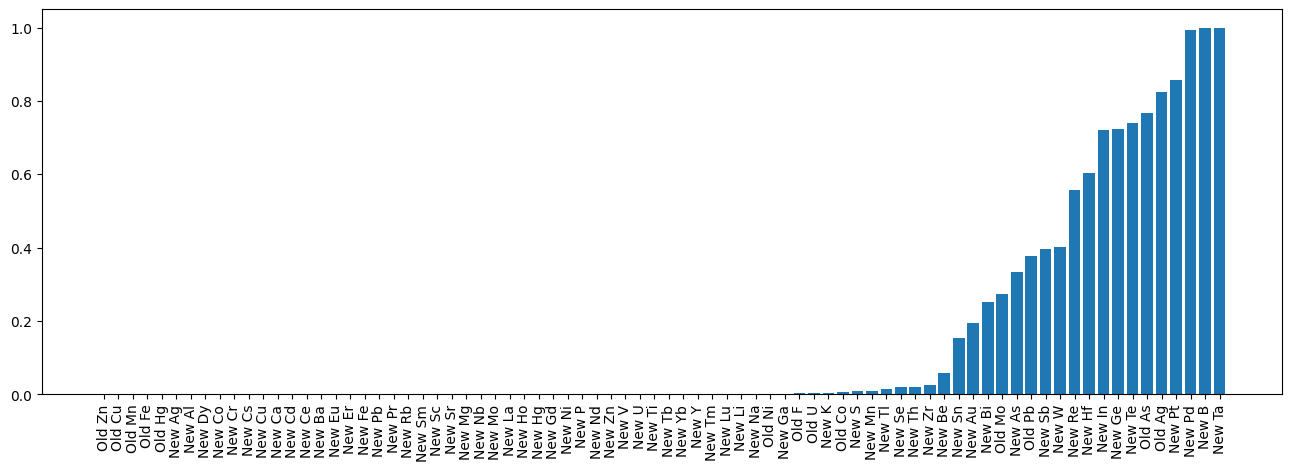

In [8]:
# Visualising null/missing values per element
count_df = count_df.sort_values(by = 'Fraction Missing')
plt.figure(figsize = (16, 5))
plt.bar(count_df.Element, count_df['Fraction Missing'])
plt.xticks(rotation = 90)
plt.show()

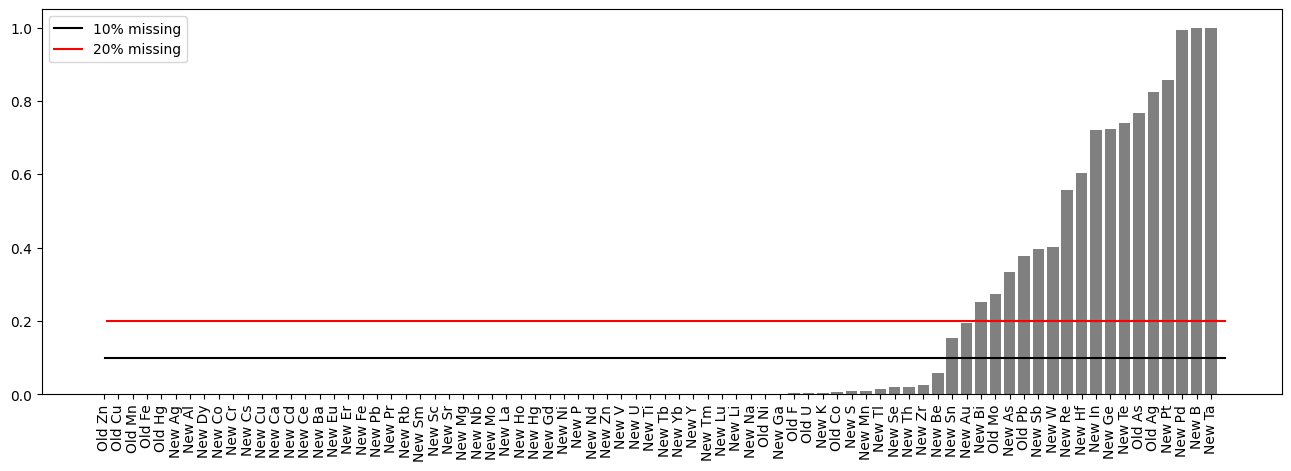

In [9]:
# Visualing missing values with cutoff
plt.figure(figsize = (16, 5))

plt.bar(count_df.Element, count_df['Fraction Missing'], color = 'grey')


plt.plot([len(count_df.Element), 0.1], [0.1, 0.1], color = 'black', label = '10% missing')
plt.plot([len(count_df.Element), 0.2], [0.2, 0.2], color = 'red', label = '20% missing')

plt.legend()
plt.xticks(rotation = 90)
plt.show()

-  We can see that the Element of Interest falls outside of the 10% cutoff. It is there required that we adjust this to 16% to accommodate for this element.

In [10]:
# Elements to be excluded
discard_elements = [element for element in element_lst if df[element].isna().sum()/len(df)>=0.16]

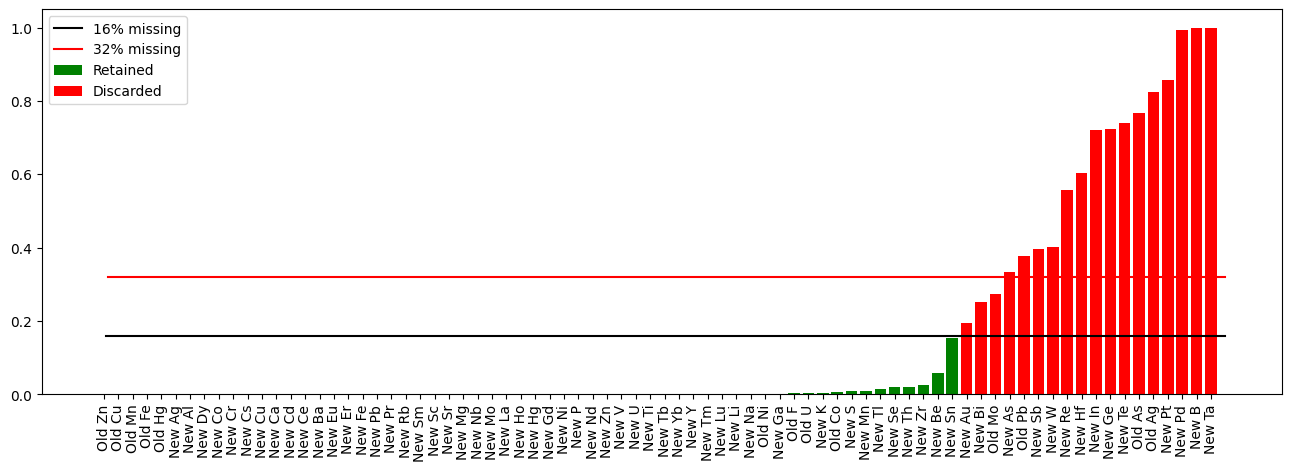

In [11]:
# Visualising them
plt.figure(figsize = (16, 5))

plt.bar(count_df.Element, count_df['Fraction Missing'], color = 'green', label = 'Retained')

plt.bar(count_df[count_df.Element.isin(discard_elements)].Element,
        count_df[count_df.Element.isin(discard_elements)]['Fraction Missing'], color = 'red', label = 'Discarded')

plt.plot([len(count_df.Element), 0.16], [0.16, 0.16], color = 'black', label = '16% missing')
plt.plot([len(count_df.Element), 0.32], [0.32, 0.32], color = 'red', label = '32% missing')

plt.legend()
plt.xticks(rotation = 90)
plt.show()

- Now we see that New Sn is within the green zone.

In [12]:
# We now reconstruct the list to create an updated list of elements
retained_elems = [element for element in element_lst if element not in discard_elements]
demo_elements = [element for element in element_lst if (df[element].isna().sum()/len(df)>0.01) and (df[element].isna().sum()/len(df)<0.16)]

### Data Imputation

In [13]:
# initialising an imputer
imputer = KNNImputer(n_neighbors=10)

In [14]:
# List of names for imputed columns
imputed_elems = ['Imputed '+elem for elem in retained_elems]
df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]))

df.describe()

,Unnamed: 0,Latitude_NAD83,Longitude_NAD83,Old Zn,Old Cu,Old Pb,Old Ni,Old Co,Old Ag,Old Mn,Old Fe,Old As,Old Mo,Old F,LOI,Old Hg,Old U,Latitude (NAD 27),Longitude (NAD 27),New Ag,New Al,New As,New Au,New B,New Ba,New Be,New Bi,New Ca,New Cd,New Ce,New Co,New Cr,New Cs,New Cu,New Dy,New Er,New Eu,New Fe,New Ga,New Gd,New Ge,New Hf,New Hg,New Ho,New In,New K,New La,New Li,New Lu,New Mg,New Mn,New Mo,New Na,New Nb,New Nd,New Ni,New P,New Pb,New Pd,New Pr,New Pt,New Rb,New Re,New S,New Sb,New Sc,New Se,New Sm,New Sn,New Sr,New Ta,New Tb,New Te,New Th,New Ti,New Tl,New Tm,New U,New V,New W,New Y,New Yb,New Zn,New Zr,Imputed Old Zn,Imputed Old Cu,Imputed Old Ni,Imputed Old Co,Imputed Old Mn,Imputed Old Fe,Imputed Old F,Imputed Old Hg,Imputed Old U,Imputed New Ag,Imputed New Al,Imputed New Ba,Imputed New Be,Imputed New Ca,Imputed New Cd,Imputed New Ce,Imputed New Co,Imputed New Cr,Imputed New Cs,Imputed New Cu,Imputed New Dy,Imputed New Er,Imputed New Eu,Imputed New Fe,Imputed New Ga,Imputed New Gd,Imputed New Hg,Imputed New Ho,Imputed New K,Imputed New La,Imputed New Li,Imputed New Lu,Imputed New Mg,Imputed New Mn,Imputed New Mo,Imputed New Na,Imputed New Nb,Imputed New Nd,Imputed New Ni,Imputed New P,Imputed New Pb,Imputed New Pr,Imputed New Rb,Imputed New S,Imputed New Sc,Imputed New Se,Imputed New Sm,Imputed New Sn,Imputed New Sr,Imputed New Tb,Imputed New Th,Imputed New Ti,Imputed New Tl,Imputed New Tm,Imputed New U,Imputed New V,Imputed New Y,Imputed New Yb,Imputed New Zn,Imputed New Zr
count,3442.00000,3441.000000,3441.000000,3441.000000,3441.000000,2143.000000,3438.000000,3416.000000,606.000000,3441.000000,3441.000000,799.000000,2496.000000,3433.000000,3436.000000,3441.000000,3430.000000,3441.000000,3441.000000,3440.000000,3440.000000,2298.000000,2772.000000,4.000000,3440.000000,3241.000000,2575.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,3434.000000,3440.000000,948.000000,1369.000000,3440.000000,3440.000000,958.000000,3427.000000,3440.000000,3439.000000,3439.000000,3440.000000,3406.000000,3440.000000,3439.000000,3440.000000,3440.000000,3440.000000,3440.000000,3440.000000,22.000000,3440.00000,490.000000,3440.000000,1524.000000,3414.000000,2079.000000,3440.000000,3373.000000,3440.000000,2909.000000,3440.000000,2.000000,3440.000000,897.000000,3368.000000,3440.000000,3393.000000,3439.000000,3440.000000,3440.000000,2056.000000,3440.000000,3440.000000,3440.000000,3355.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000,3442.000000
mean,1720.50000,55.383663,-63.778378,111.829119,28.005522,3.614559,17.569226,10.814110,0.278053,662.333333,2.686199,4.816646,6.525240,238.485290,25.832945,77.119442,3.542711,55.383561,-63.779213,175.697093,1.413776,3.125631,1.159848,22.500000,99.559273,0.731780,0.059814,0.365221,0.525137,120.534767,11.408692,24.931424,0.417125,29.778860,4.812532,2.521805,1.201087,2.659151,3.057076,6.551916,0.154536,0.084755,95.361628,0.908108,0.029081,0.076032,63.260233,6.745042,0.321093,0.244099,458.453611,5.655390,0.018914,1.128701,56.051834,22.909709,0.101501,4.739203,16.363636,15.38666,2.777551,6.815291,3.142388,0.333776,0.123959,2.904564,0.972902,8.835869,0.342970,23.004971,0.060000,0.870078,0.038874,2.501455,0.041443,0.138246,0.354181,3.464738,32.671221,0.438619,24.02485

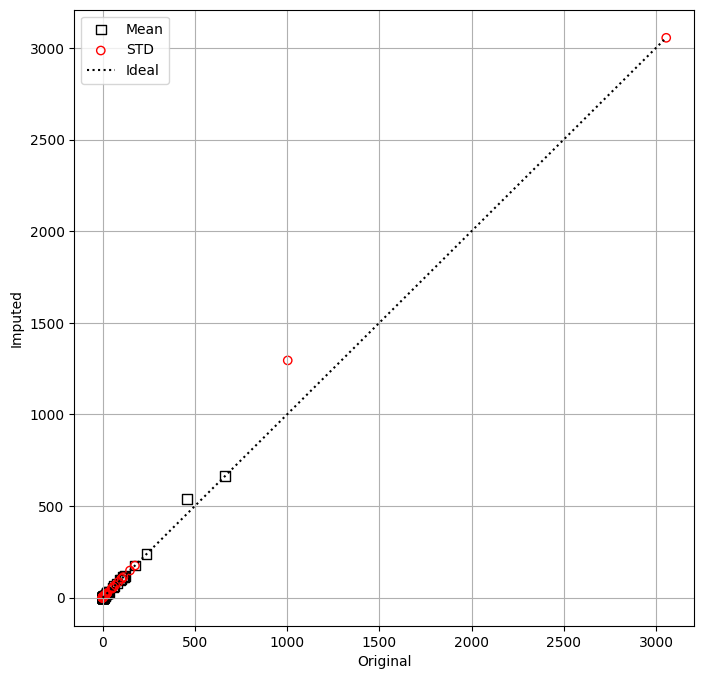

In [15]:
plt.figure(figsize = (8,8))


plt.scatter(df[retained_elems].mean(), df[imputed_elems].mean(),
            label = 'Mean', marker = 's', facecolor = 'none', edgecolor = 'black', s = 50)

plt.scatter(df[retained_elems].std(), df[imputed_elems].std(),
            label = 'STD', facecolor = 'none', edgecolor = 'red')


lim = max(max(df[retained_elems].mean()), max(df[imputed_elems].mean()), max(df[retained_elems].std()), max(df[imputed_elems].std()))



plt.plot([0,lim],[0,lim], linestyle = ':', color = 'k', label = 'Ideal')



plt.legend()
plt.xlabel('Original')
plt.ylabel('Imputed')
plt.grid()
plt.show()

In [16]:

r2_lst = []


for n in range(1, 100, 1):


    imputer = KNNImputer(n_neighbors=n, weights = 'distance')



    df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]), columns = retained_elems)



    r2_lst.append([n, r2_score(df[retained_elems].mean(), df[imputed_elems].mean()), r2_score(df[retained_elems].std(), df[imputed_elems].std())])

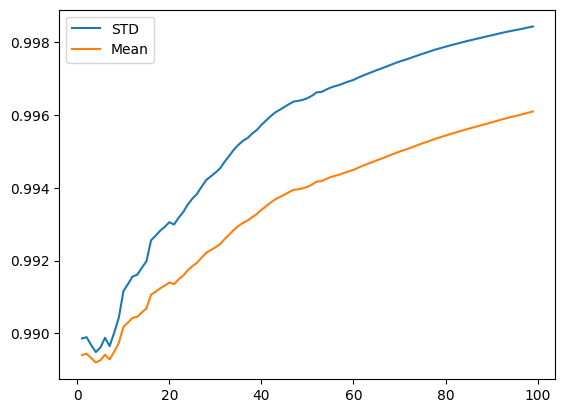

In [17]:
r2_df = pd.DataFrame(r2_lst, columns = ['N', 'Mean', 'STD'])
plt.plot(r2_df.N, r2_df.STD, label = 'STD')
plt.plot(r2_df.N, r2_df.Mean, label = 'Mean')
plt.legend()


- Looks like at high number of Neighbours, that's where accuracy on the imputed data.

(array([483.,   0., 808., 606.,   0.,   0., 431.,   0., 239.,   0., 135.,
         63.,   0.,   0.,  40.,   0.,  30.,   0.,  15.,   0.,   8.,   7.,
          0.,   7.,   0.,   3.,   0.,   4.,   0.,   0.,   2.,   4.,   0.,
          1.,   0.,   0.,   0.,   0.,   4.,   0.,   1.,   0.,   2.,   1.,
          0.,   4.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          2.,   0.,   0.,   0.,   0.,   1.,   0.,   1.,   0.,   0.,   1.,
          0.,   0.,   0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   2.,   0.,
          0.,   0.,   0.,   0.,   1.,   0.,   0.,   0.,   0.,   0.,   0.,
          1.]),
 array([0.1 , 0.15, 0.2 , 0.25, 0.3 , 0.35, 0.4 , 0.45, 0.5 , 0.55, 0.6 ,
        0.65, 0.7 , 0.75, 0.8 , 0.85, 0.9 , 0.95, 1.  , 1.05, 1.1 , 1.15,
        1.2 , 1.25, 1.3 , 1.35, 1.4 , 1.45, 1.5 , 1.55, 1.6 , 1.65, 1.7 ,
        1.75, 1.8 , 1.85, 1.9 , 1.95, 2.  , 2.05, 2.1 , 2.15, 2.2 , 2.25,
        2.3 , 2.35, 2.

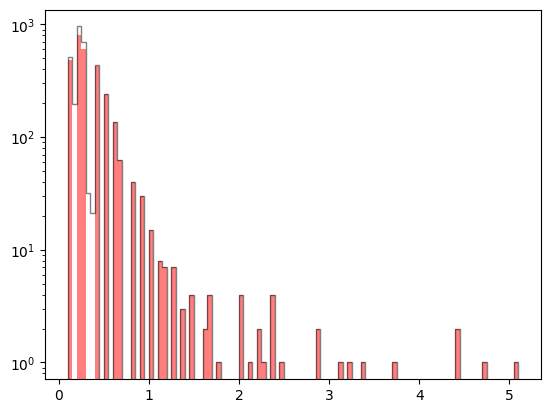

In [18]:
plt.hist(df['Imputed New Sn'], bins = 100, alpha = 0.5, histtype = 'step', log = True, color = 'k')
plt.hist(df['New Sn'], bins = 100, alpha = 0.5, log = True, color = 'red')

In [19]:
chemical = 'New Sn'

## R - Squared Method

In [20]:
r2_lst = []

for n in range(1, 100, 1):

    imputer = KNNImputer(n_neighbors=n, weights = 'distance')

    df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]), columns = retained_elems)

    imput_hist = plt.hist(df[imputed_elems[retained_elems.index(chemical)]], bins = 100, log = True)
    orig_hist = plt.hist(df[chemical].dropna(), bins = 100, range = (df[imputed_elems[retained_elems.index(chemical)]].min(), df[imputed_elems[retained_elems.index(chemical)]].max()), log = True)


    plt.close()
    r2_lst.append([n, r2_score(orig_hist[0], imput_hist[0])])


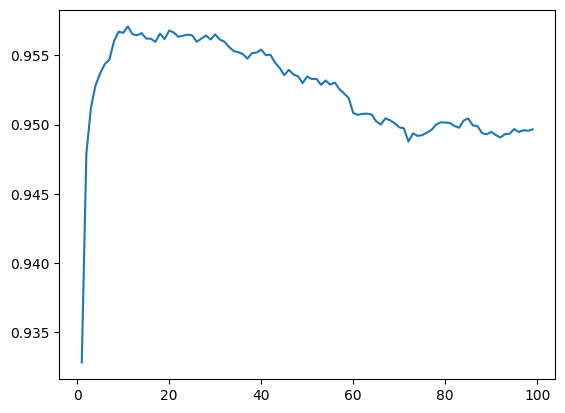

In [21]:
r2_df = pd.DataFrame(r2_lst, columns = ['N', 'R2'])

plt.plot(r2_df.N, r2_df.R2)


In [22]:
r2_df.R2.max()

0.957085335303729

In [23]:
r2_df[r2_df.R2 == r2_df.R2.max()]

,N,R2
10,11,0.957085


It looks like the only neighbours to use are only 11 based on the R^2.

In [24]:
imputer = KNNImputer(n_neighbors = 11, weights = 'distance')

df[imputed_elems] = pd.DataFrame(imputer.fit_transform(df[retained_elems]), columns = retained_elems)


## Histogram Method

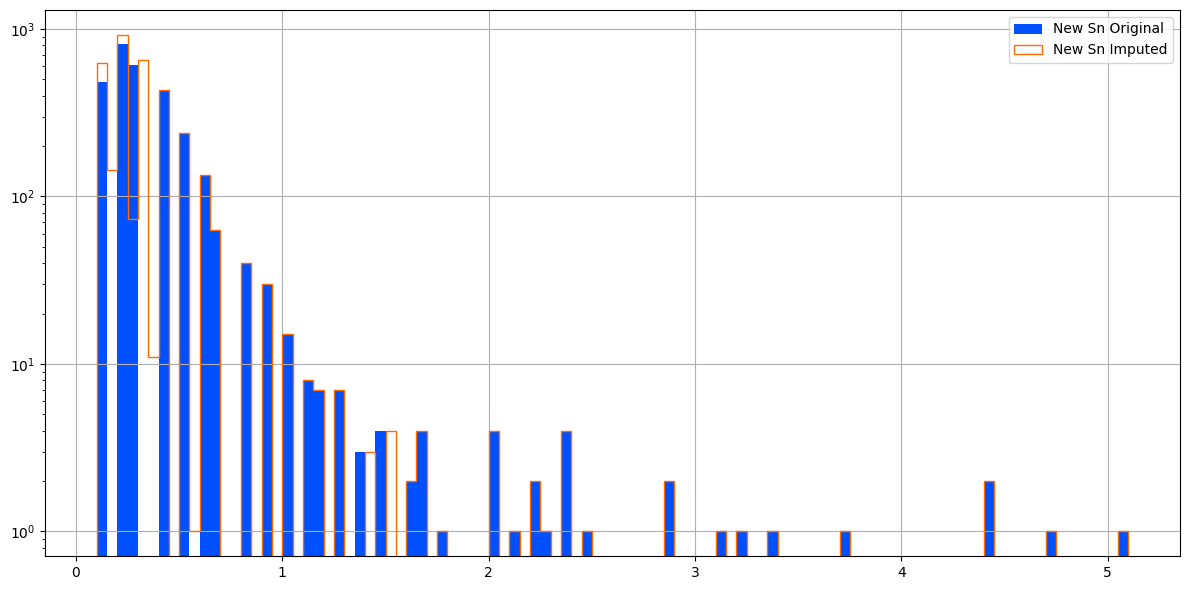

In [25]:
# Define the chemical you want to plot
chemical = 'New Sn'  # Replace with actual chemical name

# Get the index of the chemical in retained_elems
index = retained_elems.index(chemical)

# Set up the figure
fig_size_x = 6
fig_size_y = 12
fig, ax = plt.subplots(figsize=(fig_size_y, fig_size_x))

# Define colormaps
colormap1 = plt.cm.get_cmap('jet_r', len(retained_elems))
colormap2 = plt.cm.get_cmap('jet', len(retained_elems))

# Plot histograms
ax.hist(df[chemical], bins = 100, color = colormap1(index),
        label = f'{chemical} Original', log = True)
ax.hist(df[imputed_elems[index]], bins = 100, color = colormap2(index),
        label = f'{chemical} Imputed', log=True, histtype = 'step')

# Customize plot
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()


- We observe some additional bars coming from the imputed data.

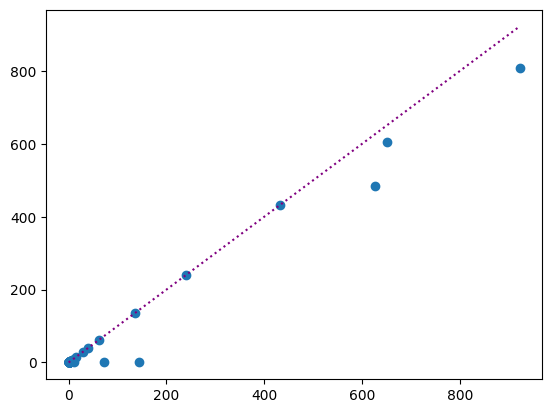

In [26]:
imput_hist = np.histogram(df[imputed_elems[retained_elems.index(chemical)]], bins = 100)
orig_hist = np.histogram(df[chemical].dropna(), bins = 100, range = (df[imputed_elems[retained_elems.index(chemical)]].min(), df[imputed_elems[retained_elems.index(chemical)]].max()))

lim = max(max(imput_hist[0]), max(orig_hist[0]))
plt.plot([0,lim],[0,lim], linestyle = ':', color = 'purple', label = 'Ideal')

plt.scatter(imput_hist[0], orig_hist[0])

We see a very good fit at low number of Neighbours.

In [27]:
demo_elements = ['New Sn']
imputed_demo_elements = ['Imputed '+element for element in demo_elements]
imputed_demo_elements

['Imputed New Sn']

Element - New Sn could not be plotted.


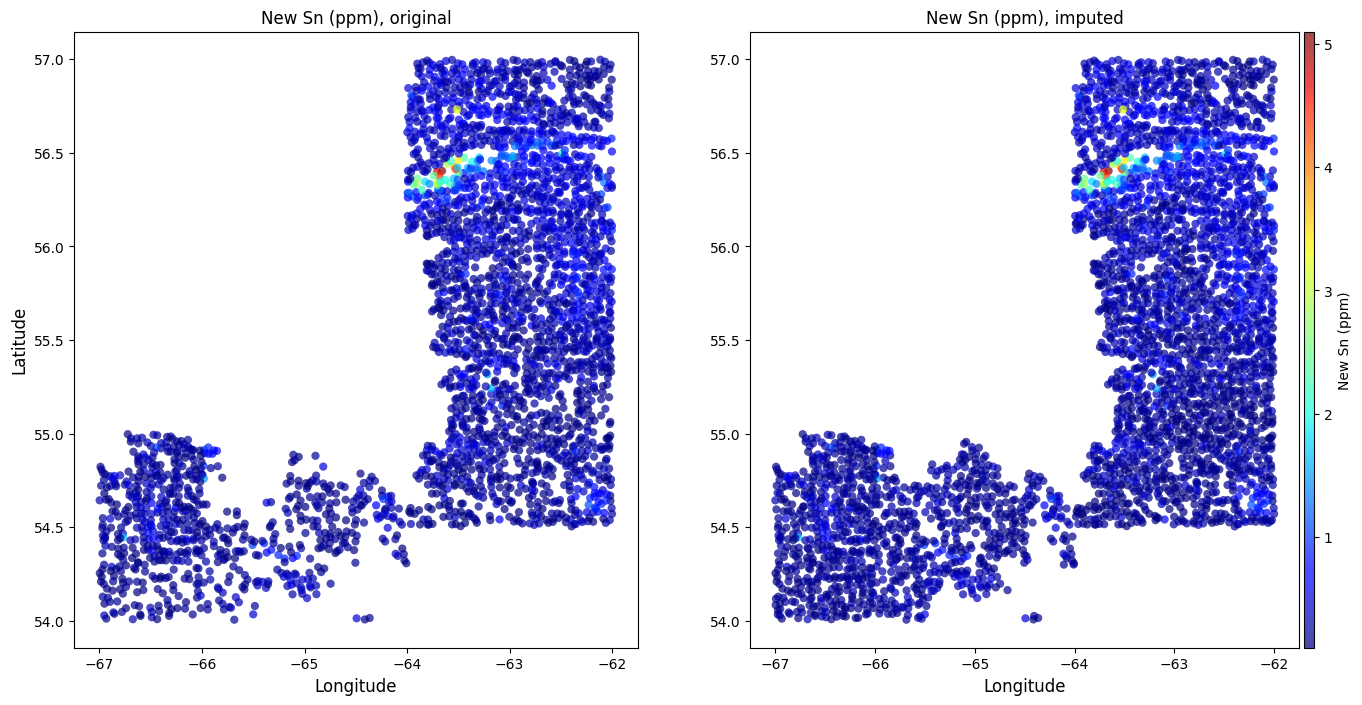

In [28]:
colormap=plt.cm.get_cmap('jet')

for element in demo_elements:
    try:
        fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (16, 8))

        ax1.set_xlabel('Longitude', fontsize = 12)
        ax1.set_ylabel('Latitude', fontsize = 12)
        ax1.set_title(element+' (ppm), original', fontsize = 12)
        ax2.set_xlabel('Longitude', fontsize = 12)
        ax2.set_ylabel('', fontsize = 12)
        ax2.set_title(element+' (ppm), imputed', fontsize = 12)

        scatter1 = ax1.scatter(df['Longitude_NAD83'], df['Latitude_NAD83'], c = df[element],
                           cmap = colormap, s = 35, alpha=0.7, label='', edgecolor = 'none')

        scatter2 = ax2.scatter(df['Longitude_NAD83'], df['Latitude_NAD83'], c = df[imputed_demo_elements[demo_elements.index(element)]],
                           cmap = colormap, s = 35, alpha=0.7, label='', edgecolor = 'none')

        divider = make_axes_locatable(ax2)
        cax = divider.append_axes( 'right', size=0.1, pad= 0.05)

        cbar2 = fig.colorbar(scatter1, pad=0.01, cax = cax)
        cbar2.set_label(element+' (ppm)')

        max_x = np.ceil(max(df['Longitude_NAD83']))
        min_x = np.floor(min(df['Latitude_NAD83']))

        ax1.set_xticks(np.arange(min_x, max_x, 1))
        ax2.set_xticks(np.arange(min_x, max_x, 1))

        plt.grid()

        plt.show()


    except:
        print("Element - "+element+" could not be plotted.")

Element - New Sn could not be plotted.


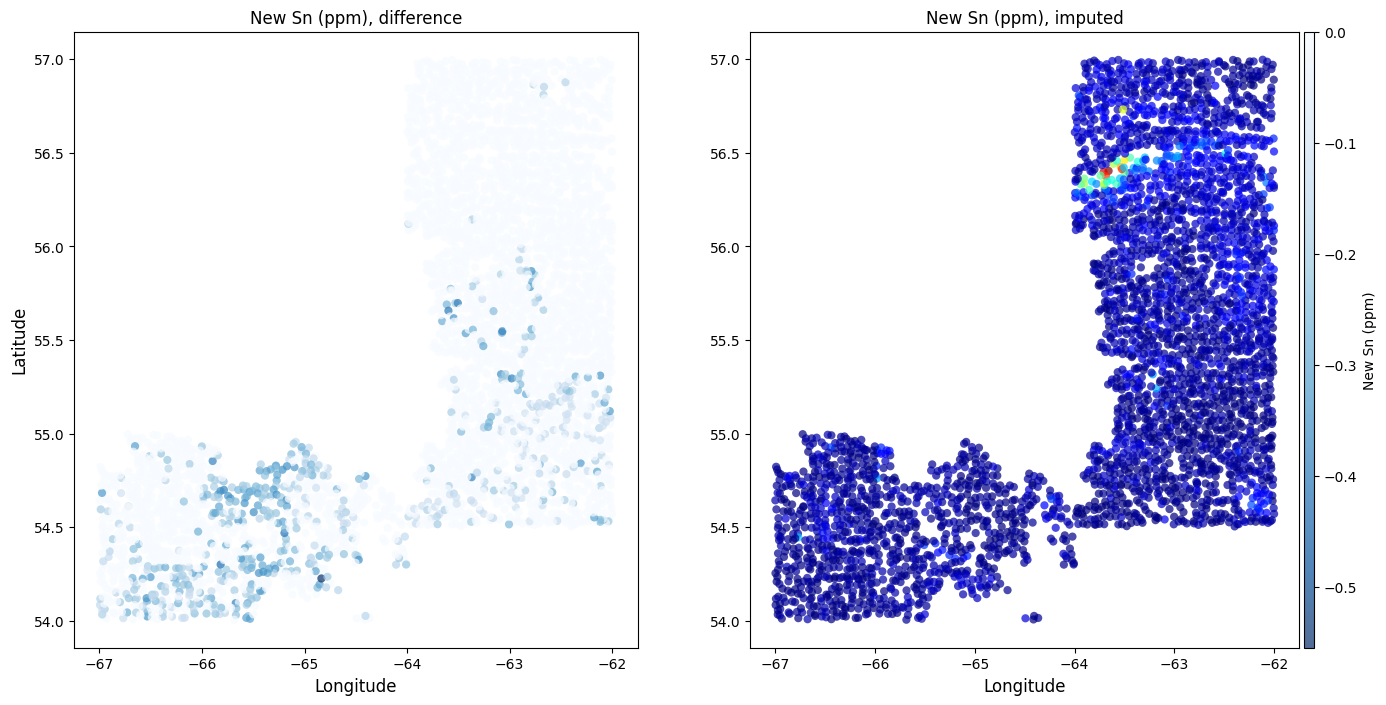

In [29]:
colormap=plt.cm.get_cmap('Blues_r')

for element in demo_elements:
    try:
        fig, [ax1, ax2] = plt.subplots(1, 2, figsize = (16, 8))

        ax1.set_xlabel('Longitude', fontsize = 12)
        ax1.set_ylabel('Latitude', fontsize = 12)
        ax1.set_title(element+' (ppm), difference', fontsize = 12)
        ax2.set_xlabel('Longitude', fontsize = 12)
        ax2.set_ylabel('', fontsize = 12)
        ax2.set_title(element+' (ppm), imputed', fontsize = 12)

        temp_df = df[element].copy()
        temp_df[temp_df.isna()] = 0


        scatter1 = ax1.scatter(df['Longitude_NAD83'], df['Latitude_NAD83'], c = temp_df-df[imputed_demo_elements[demo_elements.index(element)]],
                           cmap = colormap, s = 35, alpha=0.7, label='', edgecolor = 'none')

        scatter2 = ax2.scatter(df['Longitude_NAD83'], df['Latitude_NAD83'], c = df[imputed_demo_elements[demo_elements.index(element)]],
                           cmap = 'jet', s = 35, alpha=0.7, label='', edgecolor = 'none')


        divider = make_axes_locatable(ax2)
        cax = divider.append_axes( 'right', size=0.1, pad= 0.05)

        cbar2 = fig.colorbar(scatter1, pad=0.01, cax = cax)
        cbar2.set_label(element+' (ppm)')

        max_x = np.ceil(max(df['Longitude_NAD83']))
        min_x = np.floor(min(df['Latitude_NAD83']))

        ax1.set_xticks(np.arange(min_x, max_x, 1))
        ax2.set_xticks(np.arange(min_x, max_x, 1))
        plt.grid()

        plt.show()


    except:
        print("Element - "+element+" could not be plotted.")

### Assignment - Conclusion


- The from the mean and std deviation of R-squared, what we saw was the accuracy getting high at high number of Neighbors. But once we look at what we get the Using a holdout validation approach, we found that *k = 11* gives the best performance.  
- When we compare the distribution of the original data to the imputed data using histograms and like of best fit (between original data and imputed data),  we notice that lower *k* values  tend to match the original shape more closely.  

- Clearly it is not too obvious, at first, one may expect higher values for neighbours.



